In [159]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [160]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [161]:
pd.read_sql('SELECT * FROM checker LIMIT 1', conn)

,index,status,success,timestamp,numTrials,labname,uid
0,0,checking,0,2020-04-16 21:12:50.740474,5,None,admin_1


In [162]:
query = '''
SELECT
    timestamp AS datetime
FROM checker
WHERE
    uid LIKE 'user%'
'''

In [163]:
df = pd.read_sql(query, conn)
df

,datetime
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [164]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [165]:
df['hour'] = df['datetime'].dt.hour

In [166]:
df['day_of_week'] = df['datetime'].dt.dayofweek

In [167]:
weekday_commits = df[(df['day_of_week'] >= 0) & (df['day_of_week'] <= 4)]

In [168]:
weekday_commits

,datetime,hour,day_of_week
0,2020-04-17 05:19:02.744528,5,4
1,2020-04-17 05:22:35.249331,5,4
2,2020-04-17 05:22:45.549397,5,4
3,2020-04-17 05:34:14.691200,5,4
4,2020-04-17 05:34:24.422370,5,4
...,...,...,...
3202,2020-05-21 20:19:06.872761,20,3
3203,2020-05-21 20:22:41.785725,20,3
3204,2020-05-21 20:22:41.877806,20,3
3205,2020-05-21 20:37:00.129678,20,3


In [169]:
weekend_commits = df[(df['day_of_week'] >= 5)]
weekend_commits

,datetime,hour,day_of_week
23,2020-04-18 07:56:45.408648,7,5
24,2020-04-18 13:36:53.971502,13,5
25,2020-04-18 13:42:35.482008,13,5
26,2020-04-18 13:51:22.291271,13,5
27,2020-04-18 13:53:17.230725,13,5
...,...,...,...
3088,2020-05-17 22:23:05.744415,22,6
3089,2020-05-17 22:23:11.078664,22,6
3090,2020-05-17 22:23:11.220412,22,6
3091,2020-05-17 22:25:15.051189,22,6


In [170]:
weekday_commits = list(weekday_commits['hour'])

In [171]:
weekday_commits

[5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 12,
 12,
 11,
 11,
 14,
 14,
 14,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 17,
 17,
 17,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 18,
 18,
 18,
 18,
 18,
 18,
 19,
 19,
 20,
 20,
 20,
 20,
 20,
 20,
 22,
 22,
 12,
 13,
 13,
 13,
 18,
 18,
 18,
 18,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 19,
 20,
 21,
 21,
 21,
 22,
 22,
 22,
 22,
 22,
 22,
 0,
 0,
 7,
 7,
 8,
 8,
 8,
 8,
 11,
 11,
 12,
 12,
 12,
 12,
 13,
 13,
 13,
 13,
 14,
 14,
 14,
 14,
 14,
 20,
 20,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 10,
 10,
 16,
 16,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 22,
 22,
 3,
 3,
 8,
 8,
 21,
 21,
 11,
 11,
 11,
 11,
 16,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 22,
 22,
 22,
 22,
 22,
 22,
 5,
 5,
 7,
 7,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 11,
 15,
 15,
 15,
 15,
 18,

In [172]:
weekend_commits = list(weekend_commits['hour'])

In [173]:
weekend_commits

[7,
 13,
 13,
 13,
 13,
 13,
 14,
 14,
 14,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 18,
 18,
 18,
 18,
 18,
 18,
 18,
 18,
 19,
 19,
 19,
 19,
 19,
 19,
 20,
 20,
 20,
 20,
 21,
 21,
 21,
 21,
 21,
 22,
 22,
 22,
 22,
 22,
 0,
 0,
 5,
 5,
 9,
 9,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 11,
 11,
 11,
 11,
 11,
 13,
 13,
 13,
 13,
 18,
 18,
 18,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 3,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 9,
 9,
 9,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 14,
 14,
 14,
 14,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 15,
 16,
 16,
 16,
 16,
 16,
 16,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 17,
 18,
 18,
 18,
 18,
 18,
 18,
 18,
 18,
 19,
 19,
 19,
 19,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 22,
 22,
 22,
 23,

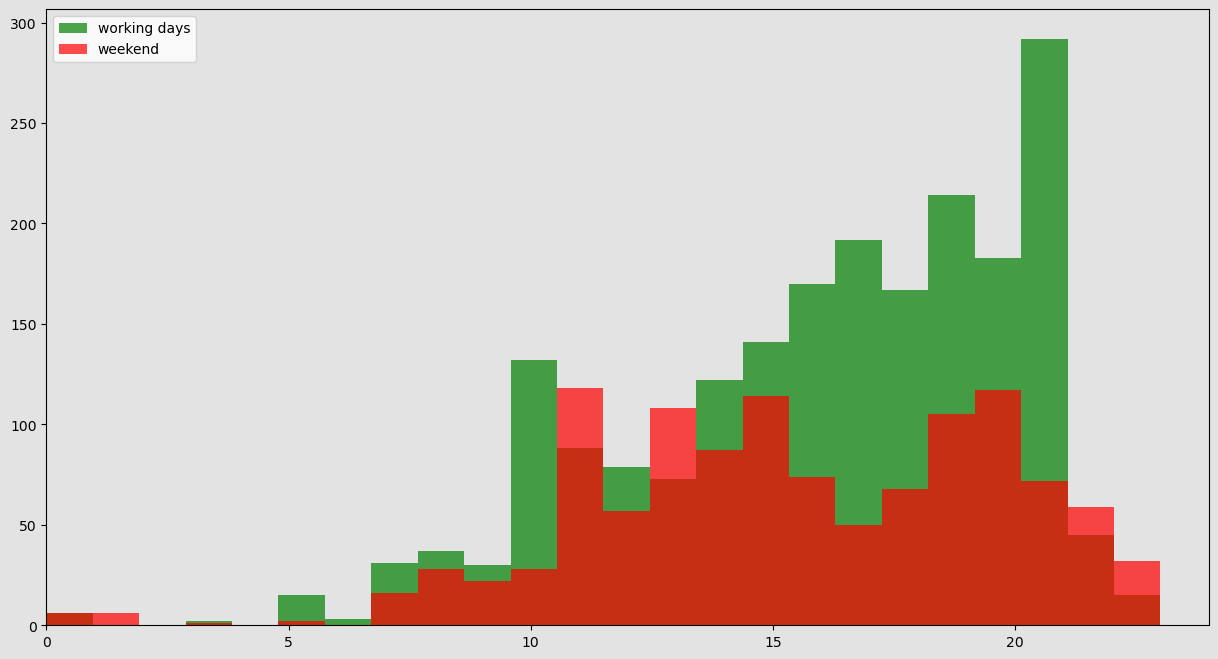

In [174]:
plt.figure(figsize=(15,8))
plt.hist(weekday_commits, bins=24, color='green', alpha=0.7, label='working days')
plt.hist(weekend_commits, bins=24, color='red', alpha=0.7, label='weekend')

plt.xlim([0, 24])
plt.legend()
plt.gcf().set_facecolor('#E3E3E3')
plt.gca().set_facecolor('#E3E3E3')

## Are there hours when the total number of commits was higher on weekends than on working days?

Top-4 examples: 11, 13, 22, 23

In [175]:
conn.close()